4th Order Inverse Coefficients:
[-1.93206883  6.55956726 -6.76333663  3.07087366  0.02600503]


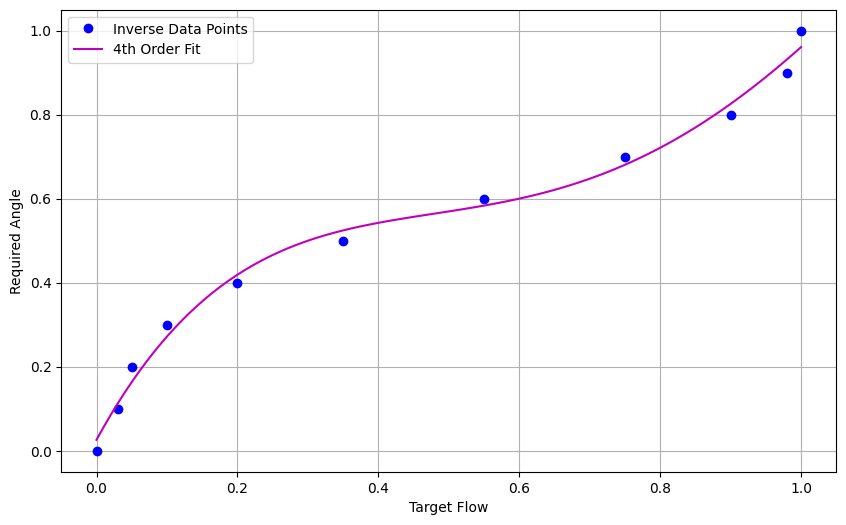

In [4]:
# Trying 4th order for better fit at the ends
degree_inv_4 = 4
coeffs_angle_vs_flow_4 = np.polyfit(y_data, x_data, degree_inv_4)
poly_angle_4 = np.poly1d(coeffs_angle_vs_flow_4)

print("4th Order Inverse Coefficients:")
print(coeffs_angle_vs_flow_4)

# Visualize 4th order
plt.figure(figsize=(10, 6))
plt.plot(y_data, x_data, 'bo', label='Inverse Data Points')
plt.plot(y_fit_inv, poly_angle_4(y_fit_inv), 'm-', label='4th Order Fit')
plt.xlabel('Target Flow')
plt.ylabel('Required Angle')
plt.legend()
plt.grid(True)
plt.show()

# C++ Code Generation
Based on the inverse coefficients, we can generate a C++ function for Arduino.
The polynomial is of the form:
$Angle = C_3 \cdot Flow^3 + C_2 \cdot Flow^2 + C_1 \cdot Flow + C_0$ 
Wait, usually higher order polynomials are better for S-curves. Let's check 4th order.

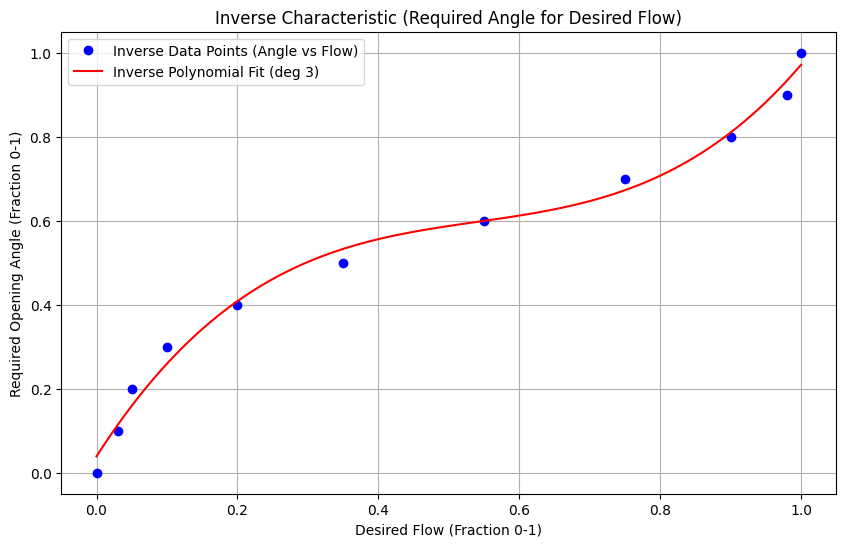

Inverse Function Coefficients (Angle = g(Flow)):
[ 2.71521639 -4.40207093  2.6191727   0.03898503]
Required Angle for 50% Flow: 0.5875 (approx 52.9 degrees)


In [3]:
# Determine the INVERSE relationship: Angle = g(IDesiredFlow)
# To linearize flow, we want to input a linear DesiredFlow (0-1) and get the required Angle (0-1).
# So we swap x and y and fit a polynomial.

degree_inv = 3
coeffs_angle_vs_flow = np.polyfit(y_data, x_data, degree_inv)
poly_angle = np.poly1d(coeffs_angle_vs_flow)

y_fit_inv = np.linspace(0, 1, 100)
x_fit_inv = poly_angle(y_fit_inv)

plt.figure(figsize=(10, 6))
plt.plot(y_data, x_data, 'bo', label='Inverse Data Points (Angle vs Flow)')
plt.plot(y_fit_inv, x_fit_inv, 'r-', label=f'Inverse Polynomial Fit (deg {degree_inv})')
plt.title('Inverse Characteristic (Required Angle for Desired Flow)')
plt.xlabel('Desired Flow (Fraction 0-1)')
plt.ylabel('Required Opening Angle (Fraction 0-1)')
plt.grid(True)
plt.legend()
plt.show()

print("Inverse Function Coefficients (Angle = g(Flow)):")
print(coeffs_angle_vs_flow)

# Verification
# If we ask for 0.5 flow (50%), what angle do we need?
target_flow = 0.5
required_angle = poly_angle(target_flow)
print(f"Required Angle for 50% Flow: {required_angle:.4f} (approx {required_angle*90:.1f} degrees)")

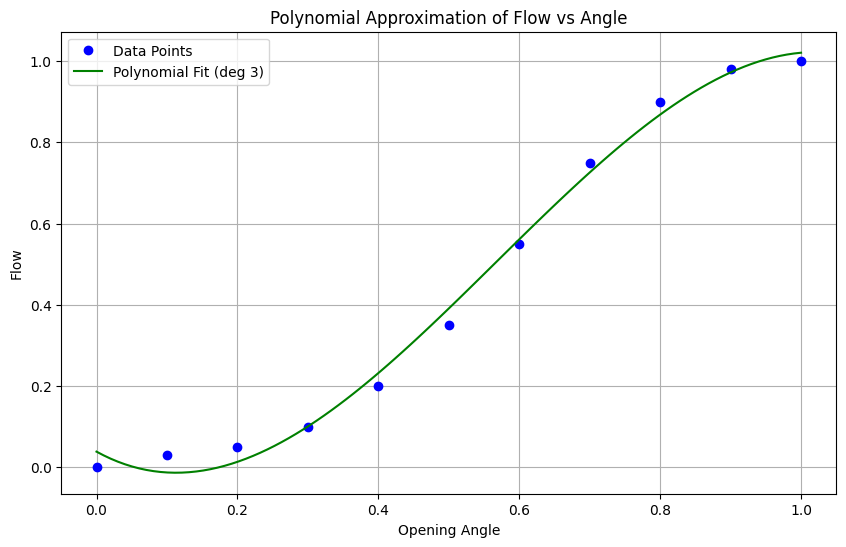

Forward Function Coefficients (Flow = f(Angle)):
[-2.76806527  4.70687646 -0.95629371  0.03832168]


In [2]:
# Fit a polynomial to the Flow vs Angle curve (Forward Function)
# We want y = f(x) where x is angle, y is flow.
# Using a 3rd degree polynomial: y = ax^3 + bx^2 + cx + d
# Note: since (0,0) and (1,1) are fixed, d should ideally be close to 0.

degree = 3
coeffs_flow_vs_angle = np.polyfit(x_data, y_data, degree)
poly_flow = np.poly1d(coeffs_flow_vs_angle)

x_fit = np.linspace(0, 1, 100)
y_fit = poly_flow(x_fit)

plt.figure(figsize=(10, 6))
plt.plot(x_data, y_data, 'bo', label='Data Points')
plt.plot(x_fit, y_fit, 'g-', label=f'Polynomial Fit (deg {degree})')
plt.title('Polynomial Approximation of Flow vs Angle')
plt.xlabel('Opening Angle')
plt.ylabel('Flow')
plt.legend()
plt.grid(True)
plt.show()

print("Forward Function Coefficients (Flow = f(Angle)):")
print(coeffs_flow_vs_angle)

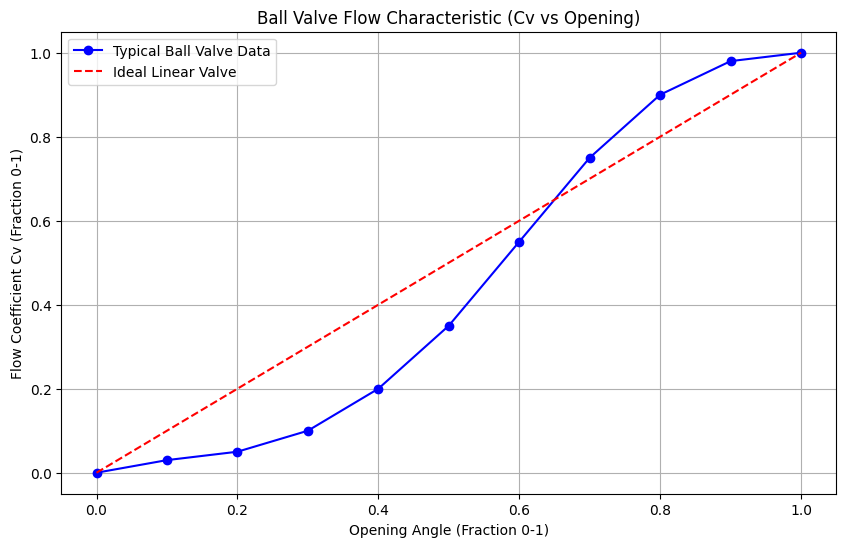

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Standard typical data points for a full port ball valve
# Opening Angle % (0-100) -> Flow Coefficient Cv % (0-100)
# Based on typical manufacturer curves for full bore ball valves.
angle_percent = np.array([0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100])
flow_percent = np.array([0, 3, 5, 10, 20, 35, 55, 75, 90, 98, 100])

# Normalize to 0.0 - 1.0 range for calculation
x_data = angle_percent / 100.0
y_data = flow_percent / 100.0

plt.figure(figsize=(10, 6))
plt.plot(x_data, y_data, 'bo-', label='Typical Ball Valve Data')
plt.plot([0, 1], [0, 1], 'r--', label='Ideal Linear Valve')
plt.title('Ball Valve Flow Characteristic (Cv vs Opening)')
plt.xlabel('Opening Angle (Fraction 0-1)')
plt.ylabel('Flow Coefficient Cv (Fraction 0-1)')
plt.grid(True)
plt.legend()
plt.show()

# Ball Valve Flow Characteristic Analysis

This notebook analyzes the relationship between the opening angle and flow percentage (Cv) for a standard full port ball valve.
We will:
1.  Define standard industry data points for flow vs angle.
2.  Fit a curve to this data.
3.  Determine the inverse relationship (Angle vs Flow) to achieve linear flow.
4.  Generate a C++ function for Arduino to implement this linearization.

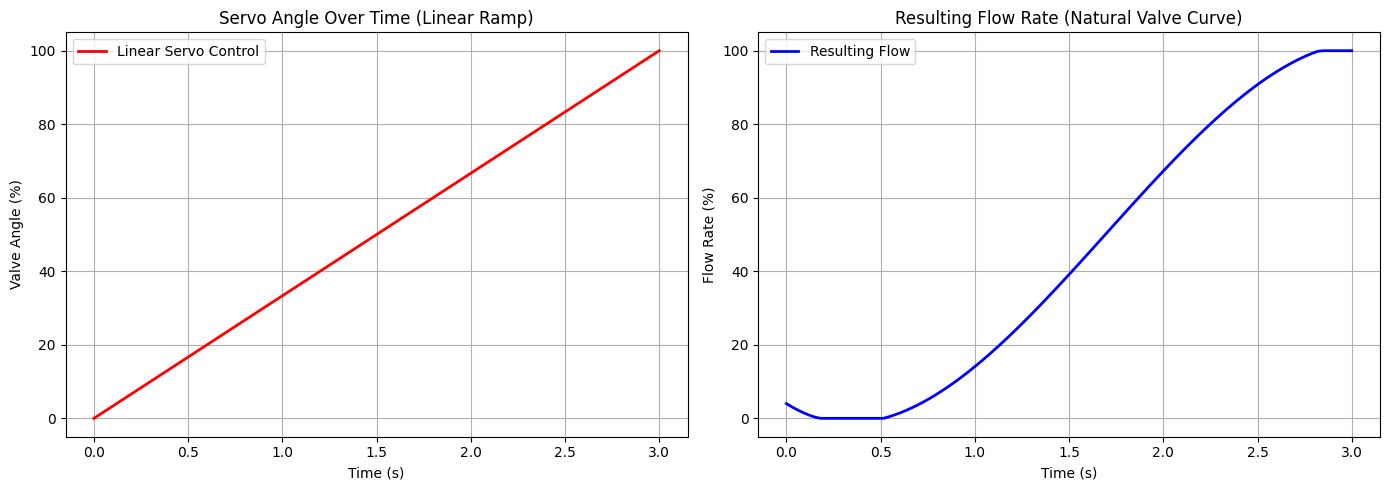

Time=0.0s | Angle=0%   | Actual Flow=4.0%
Time=1.5s | Angle=50%  | Actual Flow=40.0% (Note: < 50% due to valve shape)
Time=3.0s | Angle=100% | Actual Flow=100.0%


In [6]:
import numpy as np
import matplotlib.pyplot as plt

# --- 1. Define the System Models ---

# Forward Model (The Physical Reality): Flow % = f(Angle %)
# Based on typical full port ball valve curve (Equal Percentage-ish)
def get_actual_flow(angle_fraction):
    # Clamp input
    a = np.clip(angle_fraction, 0.0, 1.0)
    # Polynomial approximation of valve characteristic
    # Flow = -2.77*a^3 + 4.71*a^2 - 0.96*a + 0.04
    flow = -2.77 * a**3 + 4.71 * a**2 - 0.96 * a + 0.04
    return np.clip(flow, 0.0, 1.0)

# --- 2. Simulate the Firing Sequence (Linear Servo Ramp) ---

# Time parameters
duration = 3.0 # seconds
steps = 100
time = np.linspace(0, duration, steps)

# Arrays to store simulation data
linear_angle_history = []
actual_flow_history = []

for t in time:
    # Linear Servo Ramp: Angle increases linearly with time
    angle_fraction = t / duration
    linear_angle_history.append(angle_fraction)
    
    # Calculate Resulting Actual Flow using the Forward Model
    result_flow = get_actual_flow(angle_fraction)
    actual_flow_history.append(result_flow)

# --- 3. Plot Results ---

plt.figure(figsize=(14, 5))

# Subplot 1: The Control Signal
plt.subplot(1, 2, 1)
plt.plot(time, np.array(linear_angle_history) * 100, 'r-', linewidth=2, label='Linear Servo Control')
plt.title('Servo Angle Over Time (Linear Ramp)')
plt.xlabel('Time (s)')
plt.ylabel('Valve Angle (%)')
plt.grid(True)
plt.legend()

# Subplot 2: The Resulting Flow
plt.subplot(1, 2, 2)
plt.plot(time, np.array(actual_flow_history) * 100, 'b-', linewidth=2, label='Resulting Flow')
plt.title('Resulting Flow Rate (Natural Valve Curve)')
plt.xlabel('Time (s)')
plt.ylabel('Flow Rate (%)')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

# Print Verification
print(f"Time=0.0s | Angle=0%   | Actual Flow={actual_flow_history[0]*100:.1f}%")
print(f"Time=1.5s | Angle=50%  | Actual Flow={actual_flow_history[steps//2]*100:.1f}% (Note: < 50% due to valve shape)")
print(f"Time=3.0s | Angle=100% | Actual Flow={actual_flow_history[-1]*100:.1f}%")